In [1]:
## Imports + paths
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

DATA_DIR  = Path('/mnt/nasquatch/data/RNAseq/allenV1_SMART-seq')
CACHE_DIR = DATA_DIR / 'cache'
SRC_DIR   = Path('/mnt/nasquatch/data/analysis/josh/allen-scRNAseq-analysis/src')
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

sc.settings.verbosity = 1
plt.rcParams['figure.dpi'] = 120

In [2]:
## Load L2/3 cells — both excitatory and inhibitory
import data_loader

SUPERFICIAL_LAYERS = ['L1', 'L1-L2/3', 'L1-L4', 'L1-L6', 'L2/3', 'L2/3-L4', 'L4']

adata = data_loader.load_allen_filtered(
    metadata_path=str(DATA_DIR / 'mouse_VISp_2018-06-14_samples-columns.csv'),
    expression_path=str(DATA_DIR / 'mouse_VISp_2018-06-14_exon-matrix.csv'),
    target_class=None,          # load all classes
    target_layers=SUPERFICIAL_LAYERS,
    genes_path=str(DATA_DIR / 'mouse_VISp_2018-06-14_genes-rows.csv'),
    layer_name='counts',
)
print(f'\nTotal cells: {adata.n_obs}')
print(adata.obs['class'].value_counts())

Loading metadata from /mnt/nasquatch/data/RNAseq/allenV1_SMART-seq/mouse_VISp_2018-06-14_samples-columns.csv...
Loaded metadata: 15413 cells × 49 columns
Key columns: ['class', 'subclass', 'cluster']
Metadata filter: 7839 of 15413 cells selected (class=None, layers=['L1', 'L1-L2/3', 'L1-L4', 'L1-L6', 'L2/3', 'L2/3-L4', 'L4'], clusters=None)
Loading expression matrix from /mnt/nasquatch/data/RNAseq/allenV1_SMART-seq/mouse_VISp_2018-06-14_exon-matrix.csv...
  Reading 7839 of 15413 cell columns...
Loaded expression: 7839 cells × 45768 genes
Creating AnnData with 7839 cells

Cell classes: 6
class
Glutamatergic    3450
GABAergic        3215
No Class          376
Non-Neuronal      363
Low Quality       343
Endothelial        92
Name: count, dtype: int64

Total cells: 7839
class
Glutamatergic    3450
GABAergic        3215
No Class          376
Non-Neuronal      363
Low Quality       343
Endothelial        92
Name: count, dtype: int64


In [5]:
## Compute log1p(CPM) and extract marker genes

EXC_INH_MARKERS  = ['Gad1', 'Gad2', 'Slc32a1', 'Slc17a7']
CARDINAL_MARKERS = ['Lamp5', 'Vip', 'Sst', 'Pvalb', 'Sncg']
ALL_MARKERS      = EXC_INH_MARKERS + CARDINAL_MARKERS

# Gene symbol → column index mapping
sym_to_entrez = pd.Series(adata.var_names, index=adata.var['gene_symbol'])
sym_to_entrez = sym_to_entrez[~sym_to_entrez.index.duplicated(keep='first')]

# Raw counts → log1p(CPM)
X_counts = adata.layers['counts']
if hasattr(X_counts, 'toarray'):
    X_counts = X_counts.toarray()
X_counts = np.array(X_counts, dtype=np.float32)
total    = X_counts.sum(axis=1, keepdims=True).clip(min=1)
X_log    = np.log1p(X_counts / total * 1e6)

# Extract marker columns
marker_expr = {}
for gene in ALL_MARKERS:
    if gene in sym_to_entrez.index:
        entrez = sym_to_entrez[gene]
        col    = adata.var_names.get_loc(entrez)
        marker_expr[gene] = X_log[:, col]
    else:
        print(f'WARNING: {gene} not found in dataset')

expr_df = pd.DataFrame(marker_expr, index=adata.obs_names)
expr_df['class']    = adata.obs['class'].values
expr_df['subclass'] = adata.obs['subclass'].values

found = [g for g in ALL_MARKERS if g in marker_expr]
print(f'Extracted {len(found)} / {len(ALL_MARKERS)} markers: {found}')
print(expr_df['class'].value_counts())

Extracted 9 / 9 markers: ['Gad1', 'Gad2', 'Slc32a1', 'Slc17a7', 'Lamp5', 'Vip', 'Sst', 'Pvalb', 'Sncg']
class
Glutamatergic    3450
GABAergic        3215
No Class          376
Non-Neuronal      363
Low Quality       343
Endothelial        92
Name: count, dtype: int64


/tmp/ipykernel_766972/2493108099.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(
/tmp/ipykernel_766972/2493108099.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_766972/2493108099.py:33: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([f'Inh\n(n={n_inh})', f'Exc\n(n={n_exc})'])
/tmp/ipykernel_766972/2493108099.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(
/tmp/ipykernel_766972/2493108099.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is 

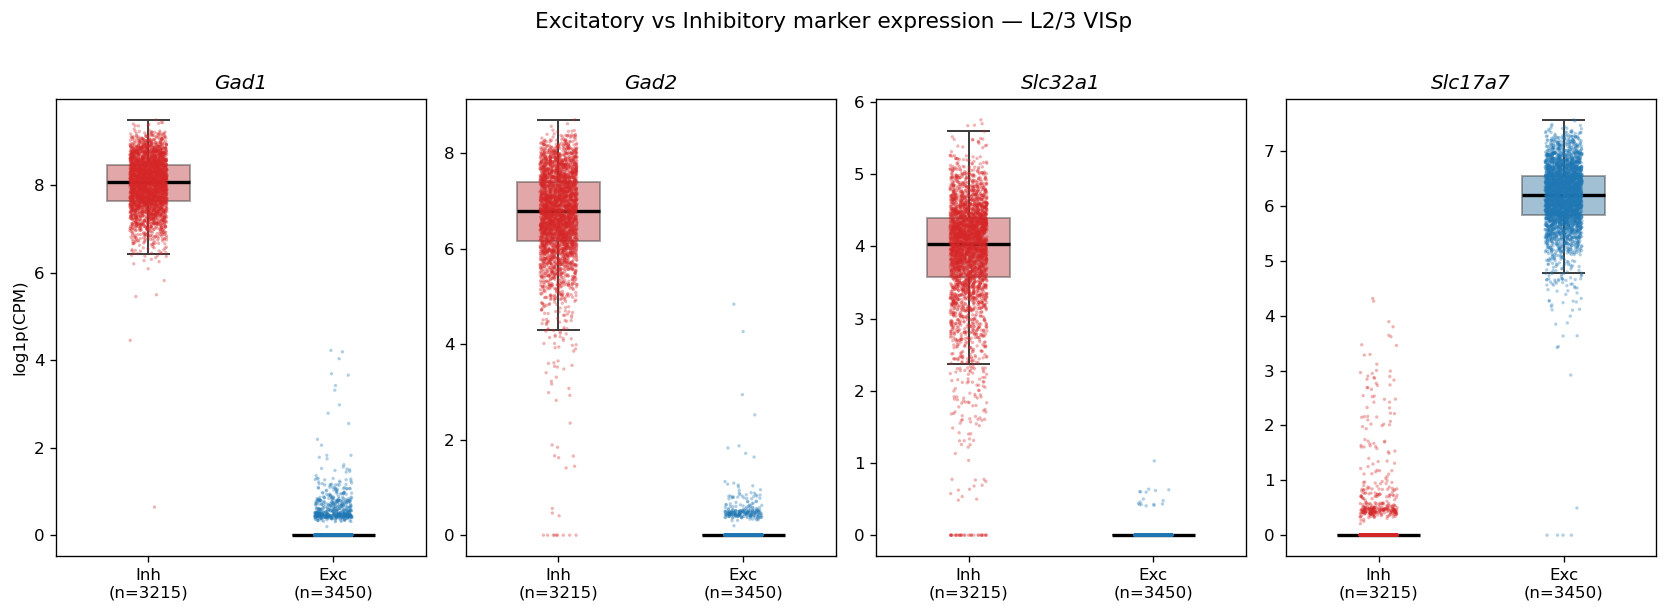

In [6]:
## Stripplot: exc/inh markers across excitatory vs inhibitory cells

CLASS_ORDER = ['GABAergic', 'Glutamatergic']
CLASS_LABELS = {'GABAergic': 'Inh', 'Glutamatergic': 'Exc'}
PALETTE = {'GABAergic': '#d62728', 'Glutamatergic': '#1f77b4'}

plot_df = expr_df[expr_df['class'].isin(CLASS_ORDER)].copy()
plot_df['class_label'] = plot_df['class'].map(CLASS_LABELS)
label_order = [CLASS_LABELS[c] for c in CLASS_ORDER]
label_palette = {CLASS_LABELS[k]: v for k, v in PALETTE.items()}

fig, axes = plt.subplots(1, len(EXC_INH_MARKERS), figsize=(3.5 * len(EXC_INH_MARKERS), 5))

for ax, gene in zip(axes, EXC_INH_MARKERS):
    sns.stripplot(
        data=plot_df, x='class_label', y=gene, order=label_order,
        palette=label_palette, ax=ax,
        size=2, alpha=0.35, jitter=True, linewidth=0,
    )
    sns.boxplot(
        data=plot_df, x='class_label', y=gene, order=label_order,
        palette=label_palette, ax=ax,
        width=0.45, fliersize=0, linewidth=1.2,
        boxprops=dict(alpha=0.45), medianprops=dict(linewidth=2, color='k'),
    )
    ax.set_title(gene, fontsize=12, style='italic')
    ax.set_xlabel('')
    ax.set_ylabel('log1p(CPM)' if ax is axes[0] else '')
    ax.tick_params(axis='x', labelsize=10)

    n_inh = (plot_df['class'] == 'GABAergic').sum()
    n_exc = (plot_df['class'] == 'Glutamatergic').sum()
    ax.set_xticklabels([f'Inh\n(n={n_inh})', f'Exc\n(n={n_exc})'])

fig.suptitle('Excitatory vs Inhibitory marker expression — L2/3 VISp', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()